# Why Does Random Forest Perform So Well? (Bias-Variance Tradeoff)

---

# 1. Understanding Bias and Variance (Layman Explanation)

Before understanding Random Forest, it's important to understand two major sources of error in Machine Learning: **Bias** and **Variance**.

### What is Bias?

Imagine a student who studies only a few pages before an exam and ignores the rest of the syllabus. Since the student has not learned enough information, they perform poorly on both practice tests and the final exam.

In Machine Learning, this is called **High Bias**.

- The model is too simple.
- It fails to learn important patterns from the training data.
- It performs poorly on both training and test datasets.
- This situation is known as **Underfitting**.

### What is Variance?

Now imagine a student who memorizes every answer from previous exams without understanding the concepts. They score extremely well on practice tests but struggle when new questions appear in the final exam.

In Machine Learning, this is called **High Variance**.

- The model learns the training data too closely.
- It memorizes noise and outliers instead of learning the true pattern.
- Training accuracy becomes very high.
- Test accuracy drops significantly.
- This situation is known as **Overfitting**.

### The Goal

An ideal Machine Learning model should:

- Learn important patterns from the training data.
- Ignore unnecessary noise and outliers.
- Generalize well to unseen data.

Random Forest helps achieve this balance by maintaining low bias while significantly reducing variance.

---

# 2. Theoretical Recap: Machine Learning Error Composition

Every predictive error generated by a Machine Learning model can be broken down into three components:

$$
\text{Total Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}
$$

### Core Definitions

#### Bias

Bias is the error introduced when a model is too simple to capture the underlying patterns in the data.

- High Bias → Underfitting
- Model is too simplistic
- Poor training and testing performance

#### Variance

Variance is the error introduced when a model becomes too sensitive to the training data.

- High Variance → Overfitting
- Model memorizes noise and outliers
- Excellent training performance but poor testing performance

### The Classical Machine Learning Dilemma

Bias and Variance generally have an inverse relationship.

Reducing one often increases the other.

Most machine learning algorithms typically fall into one of two categories:

### Low Bias, High Variance

Examples:

- Fully Grown Decision Trees
- Low-Regularized Support Vector Machines (SVMs)

### High Bias, Low Variance

Examples:

- Linear Regression
- Logistic Regression

---

# 3. Why Random Forest Outperforms Single Estimators

Random Forest is powerful because it converts a collection of:

**Low Bias + High Variance Trees**

into a single:

**Low Bias + Low Variance Ensemble**

This allows the model to maintain the learning power of deep Decision Trees while greatly improving generalization.

---

# 4. How Random Forest Reduces Variance

Assume we have:

$$
N = 10,000
$$

training samples.

Suppose 100 samples are noisy or misleading outliers.

## Single Decision Tree

A fully-grown Decision Tree tries to fit every single training point, including all noisy observations.

As a result:

- The tree creates unnecessary splits.
- The decision boundary becomes extremely complex.
- The model overfits.

This produces:

- Low Bias
- High Variance

---

## Random Forest Strategy

Random Forest applies:

### Bootstrap Sampling

Different trees receive different subsets of training rows.

### Feature Sampling

Different trees receive different subsets of features.

As a result:

- Tree 1 may see 5 noisy points.
- Tree 2 may see 10 noisy points.
- Tree 3 may see none.

The noise gets distributed across the ensemble rather than influencing every tree equally.

---

## Noise Dilution Effect

Instead of one tree being influenced by all 100 noisy points:

- Noise is spread across hundreds of trees.
- Individual errors become independent.
- Aggregation cancels many of these errors.

This dramatically reduces variance while preserving low bias.

---

# 5. Classification Example

Consider a non-linear dataset generated using:

```python
make_circles()
```

with:

- 500 samples
- 2 features

---

## Single Decision Tree Classifier

### Observations

- Decision boundary becomes highly irregular.
- Many sharp edges and isolated regions appear.
- The tree tries to classify every noisy point correctly.

### Result

- Very high training accuracy
- Poor test accuracy
- High Variance
- Overfitting

---

## Random Forest Classifier

### Observations

- Decision boundary becomes smooth.
- Boundary follows the true structure of the data.
- Local noise has minimal influence.

### Result

- Better generalization
- Lower variance
- Improved test accuracy

Random Forest may accept a tiny increase in bias to achieve a much larger reduction in variance.

---

# 6. Regression Example

Consider a non-linear regression dataset containing noise and outliers.

---

## Single Decision Tree Regressor

### Observations

- Prediction curve becomes jagged.
- The model follows every fluctuation in the data.
- Outliers heavily influence predictions.

### Result

- High Variance
- Overfitting

Example Test Error:

$$
MSE = 22.7
$$

---

## Random Forest Regressor

### Observations

- Predictions from hundreds of trees are averaged.
- Extreme predictions cancel each other out.
- The final curve becomes smooth and stable.

### Result

- Better generalization
- Lower Variance
- Improved prediction quality

Example Test Error:

$$
MSE = 15.0
$$

---

# 7. Why Random Forest Works So Well

Random Forest does not reduce variance by making Decision Trees simpler.

Instead:

1. It allows trees to grow deep and complex.
2. Maintains the low bias of individual trees.
3. Uses Bootstrap Sampling to create diversity.
4. Uses Feature Sampling to create diversity.
5. Combines predictions using:
   - Majority Voting (Classification)
   - Averaging (Regression)

Because individual errors are different across trees, aggregation cancels many of them out.

This produces:

$$
\text{Low Bias} + \text{Low Variance}
$$

which is the ideal goal in Machine Learning.

---

# 8. Key Takeaways

### Single Decision Tree

- Low Bias
- High Variance
- Prone to Overfitting

### Random Forest

- Maintains Low Bias
- Significantly Reduces Variance
- Better Generalization
- More Resistant to Noise and Outliers

### Ensemble Power

Random Forest succeeds because it combines many strong Decision Trees and averages out their mistakes.

This allows the model to capture complex patterns while remaining stable on unseen data.

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 

from sklearn.datasets import make_circles  
from sklearn.model_selection import train_test_split  

In [5]:
# Creating dataset for this practice
np.random.seed(42)
x, y = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [6]:
x.shape

(500, 2)

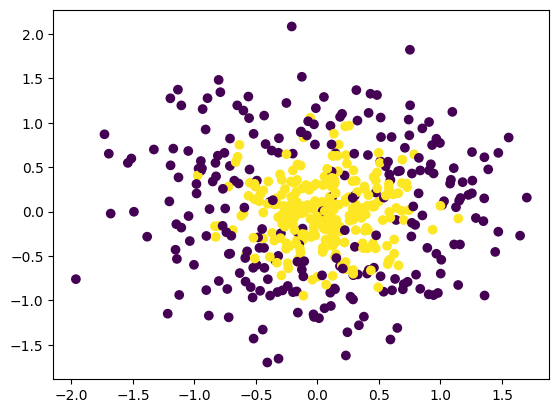

In [8]:
plt.scatter(x[:,0],x[:,1],c=y)

In [9]:
from sklearn.tree import DecisionTreeClassifier

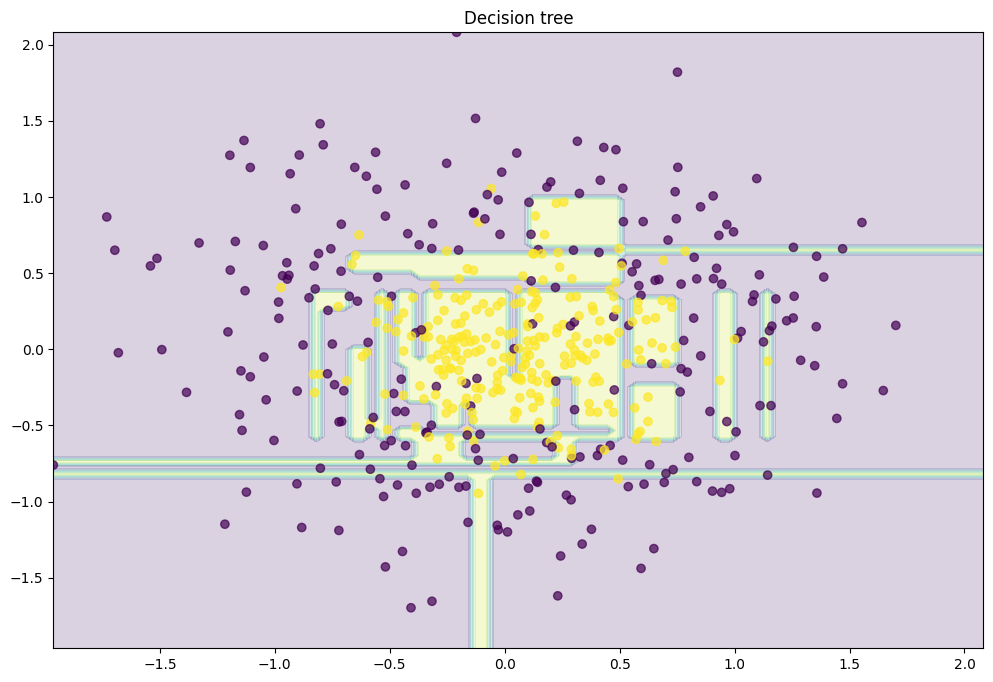

In [11]:
# How DT works ( Visual )
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(x_train, y_train)

plt.figure(figsize=(12, 8))
x_range = np.linspace(x.min(), x.max(), 100)
xx1, xx2 = np.meshgrid(x_range, x_range)
y_hat = dtree.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(x[:,0], x[:,1], c=y, cmap='viridis', alpha=.7)
plt.title("Decision tree")
plt.show()

In [12]:
# As we can see , the model tries to learn from outliers and it overfits

In [13]:
from sklearn.ensemble import RandomForestClassifier

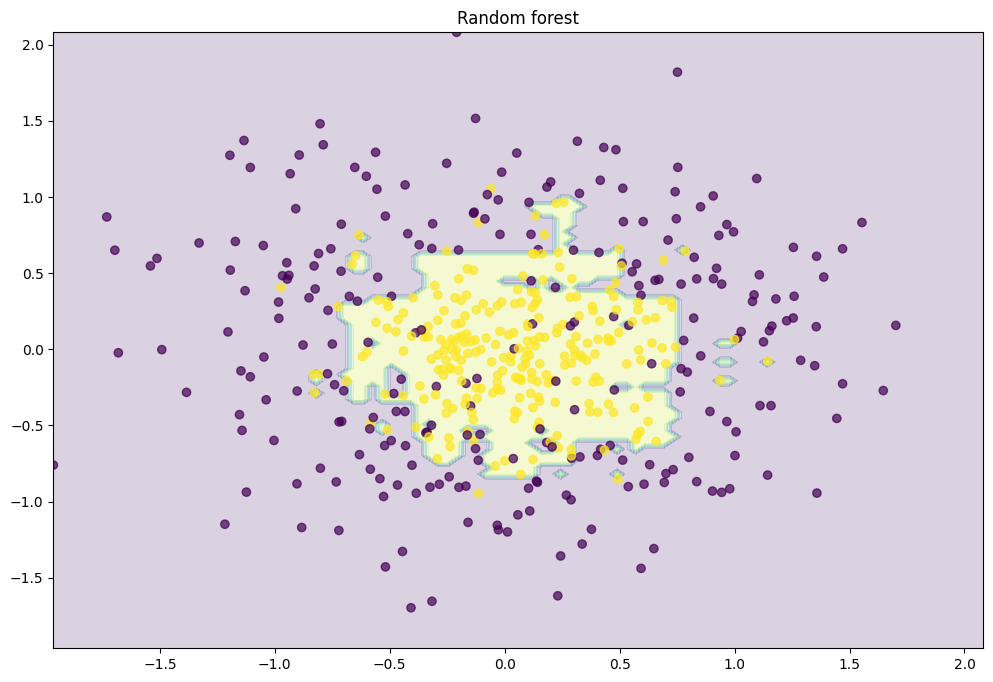

In [14]:
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(x_train, y_train)

plt.figure(figsize=(12, 8))
x_range = np.linspace(x.min(), x.max(), 100)
xx1, xx2 = np.meshgrid(x_range, x_range)
y_hat = rf.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(x[:,0], x[:,1], c=y, cmap='viridis', alpha=.7)
plt.title("Random forest")
plt.show()

In [15]:
# RF performs better then DT , even though it make some errors (ignoring outliers) , but it will perform better in test data

In [20]:
# Lets see on Regression dataset

n_train = 150        
n_test = 1000       
noise = 0.1

# Generate data
def f(x):
    x = x.ravel()
    return np.exp(-x ** 2) + 1.5 * np.exp(-(x - 2) ** 2)

def generate(n_samples, noise):
    x = np.random.rand(n_samples) * 10 - 5
    x = np.sort(x).ravel()
    y = np.exp(-x ** 2) + 1.5 * np.exp(-(x - 2) ** 2)\
        + np.random.normal(0.0, noise, n_samples)
    x = x.reshape((n_samples, 1))

    return x, y

x_train, y_train = generate(n_samples=n_train, noise=noise)
x_test, y_test = generate(n_samples=n_test, noise=noise)

(-5.0, 5.0)

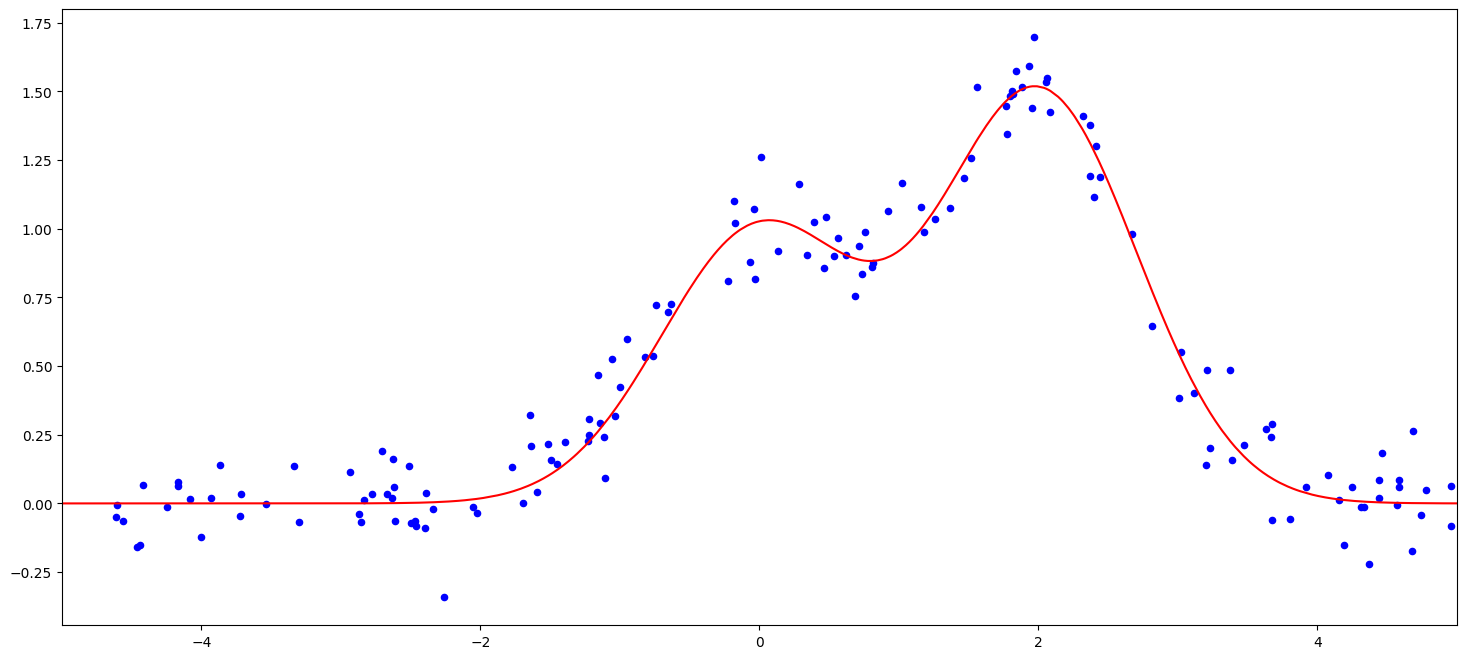

In [19]:
plt.figure(figsize=(18, 8))
plt.plot(x_test, f(x_test), "r")
plt.scatter(x_train, y_train, c="b", s=20)
plt.xlim([-5, 5])

Text(0.5, 1.0, 'Decision tree, MSE = 23.78')

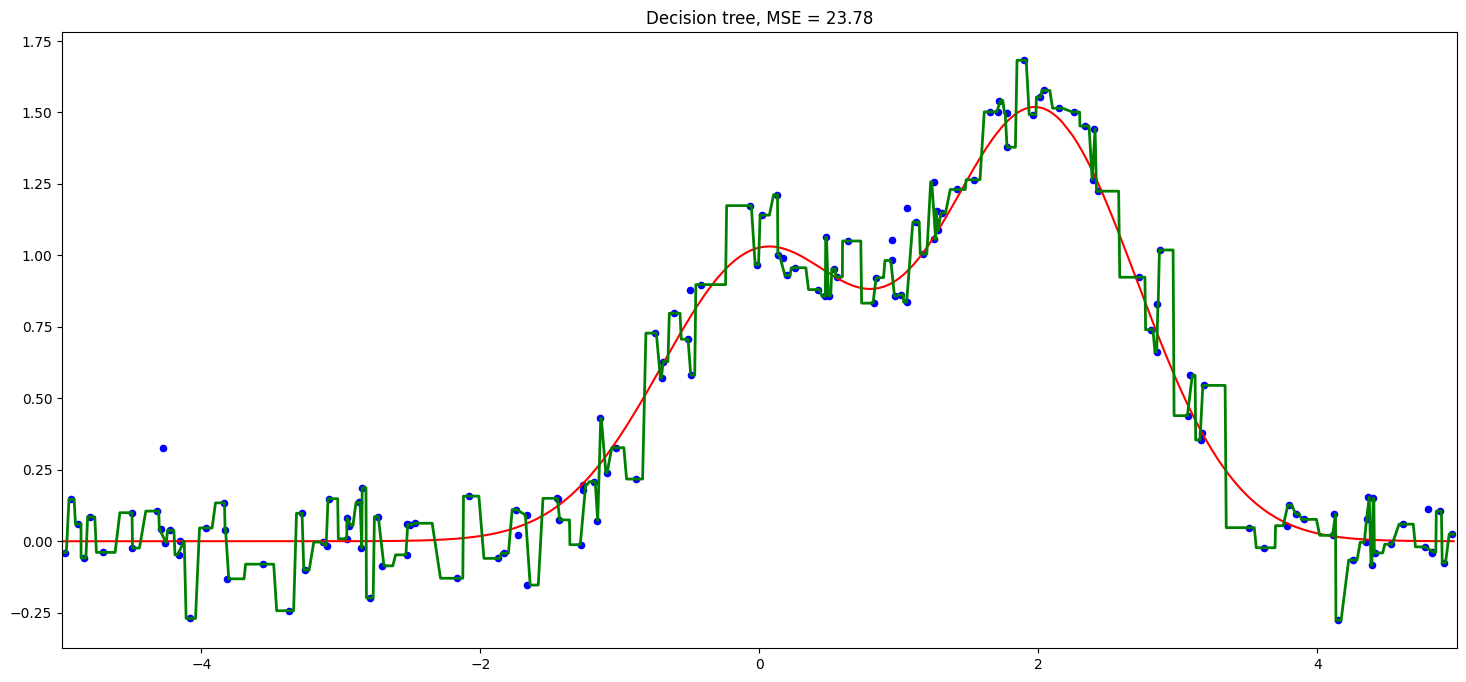

In [21]:
# One decision tree regressor
from sklearn.tree import DecisionTreeRegressor

dtree = DecisionTreeRegressor().fit(x_train, y_train)
d_predict = dtree.predict(x_test)

plt.figure(figsize=(18, 8))
plt.plot(x_test, f(x_test), "r")
plt.scatter(x_train, y_train, c="b", s=20)
plt.plot(x_test, d_predict, "g", lw=2)
plt.xlim([-5, 5])
plt.title("Decision tree, MSE = %.2f" 
          % np.sum((y_test - d_predict) ** 2))

In [22]:
# DT tries to learn from every data point -> Overfits

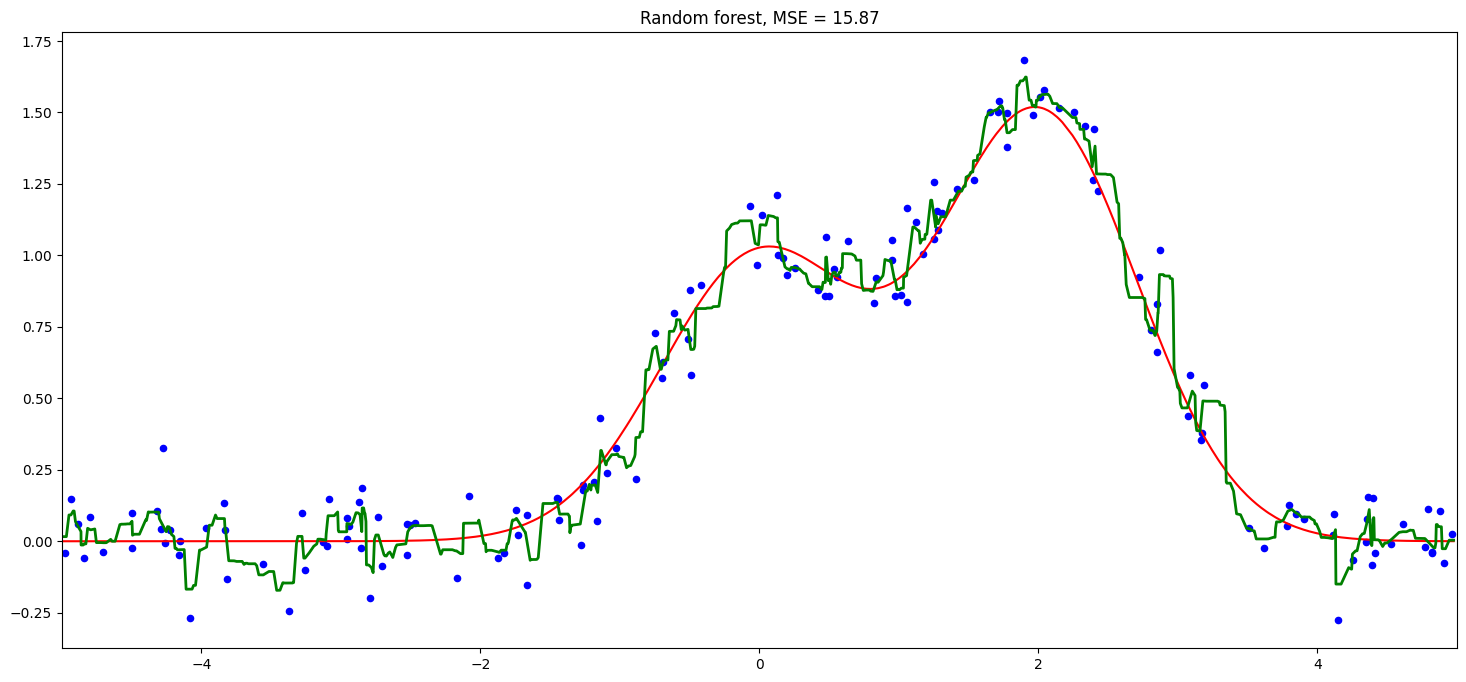

In [25]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor(n_estimators=1000).fit(x_train, y_train)
rf_predict = rfr.predict(x_test)

plt.figure(figsize=(18, 8))
plt.plot(x_test, f(x_test), "r")
plt.scatter(x_train, y_train, c="b", s=20)
plt.plot(x_test, rf_predict, "g", lw=2)
plt.xlim([-5, 5])
plt.title("Random forest, MSE = %.2f" % np.sum((y_test - rf_predict) ** 2));

In [26]:
# Performs better then DT 